In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import scipy.stats
import logomaker
from scipy.signal import correlate
import pickle

# Insert local path to MAVE-NN at beginning of Python's path
import sys
sys.path.insert(0, './mavenn')

# Import MAVE-NN
import mavenn

# Get list of demos
mavenn.run_demo()

To run a demo, execute

	>>> mavenn.run_demo(name)

where 'name' is one of the following strings:

	1. "gb1_ge_evaluation"
	2. "mpsa_ge_training"
	3. "sortseq_mpa_visualization"

Python code for each demo is located in

	/opt/miniconda3/envs/mavenn/lib/python3.12/site-packages/mavenn/examples/demos/



['gb1_ge_evaluation', 'mpsa_ge_training', 'sortseq_mpa_visualization']

In [2]:
def plot_models(model, sign_flips, reverse_complement = False):
    for sample_set_name, sign_flip in zip(model.keys(), sign_flips):

        # Retrieve G-P map parameter dict and view dict keys
        theta_dict = model[sample_set_name].get_theta(gauge='uniform')
        
        # Get the additive weights
        lc_weights = theta_dict['theta_lc']
        # Convert them to pandas dataframe
        lc_df = pd.DataFrame(lc_weights, columns=model[sample_set_name].alphabet)

        # Correct sign flips
        if sign_flip:
            lc_df = -1*lc_df

        # Reverse complement
        if reverse_complement:
            lc_df = lc_df.rename(index = dict(zip(lc_df.index, len(lc_df) - lc_df.index)), columns = {"A": "T", "C": "G", "G": "C", "T": "A"})

        # plot logos
        fig, axs = plt.subplots(1, 1, figsize=[12, 3])

        # sequence logo for the CRP-DNA binding energy matrix
        logo = logomaker.Logo(lc_df,  ax=axs, center_values=True)
        axs.set_title(sample_set_name)
        logo.style_spines(visible=False)


        # sequence logo for the RNAP-DNA binding energy matrix
        #logo = logomaker.Logo(rnap_df, ax=axs[1], center_values=True)
        #axs[1].set_title('RNAP-DNA ($\Delta G_R$)')
        #logo.style_spines(visible=False)

        plt.tight_layout()
        plt.savefig(sample_set_name + "_logo.png")
        plt.show()

Model loaded from these files:
	NGS-NZ-3454_A1-1W_A1-Out.pickle
	NGS-NZ-3454_A1-1W_A1-Out.weights.h5
Model loaded from these files:
	NGS-NZ-3454_A1-3W_A1-Out.pickle
	NGS-NZ-3454_A1-3W_A1-Out.weights.h5
Model loaded from these files:
	NGS-NZ-3454_A2-3W_A2-Out.pickle
	NGS-NZ-3454_A2-3W_A2-Out.weights.h5


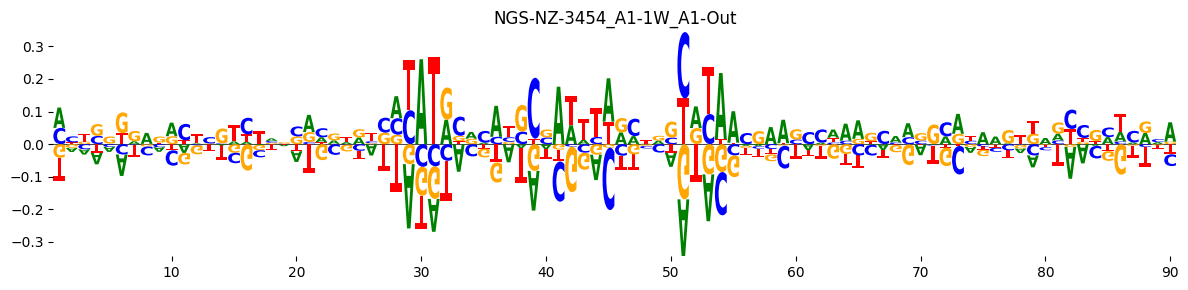

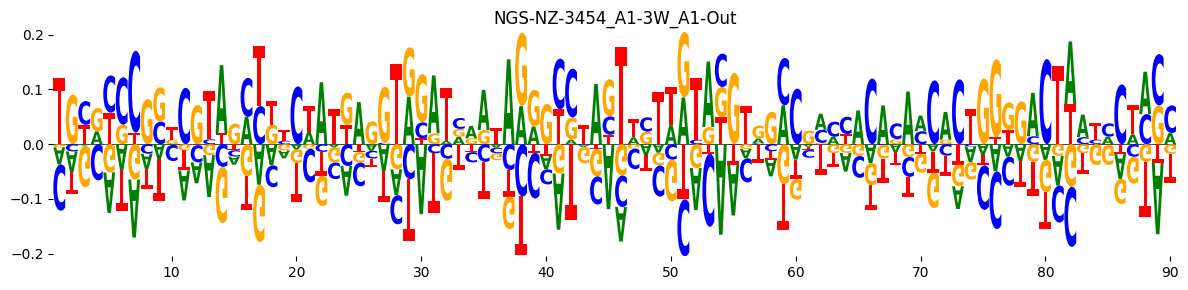

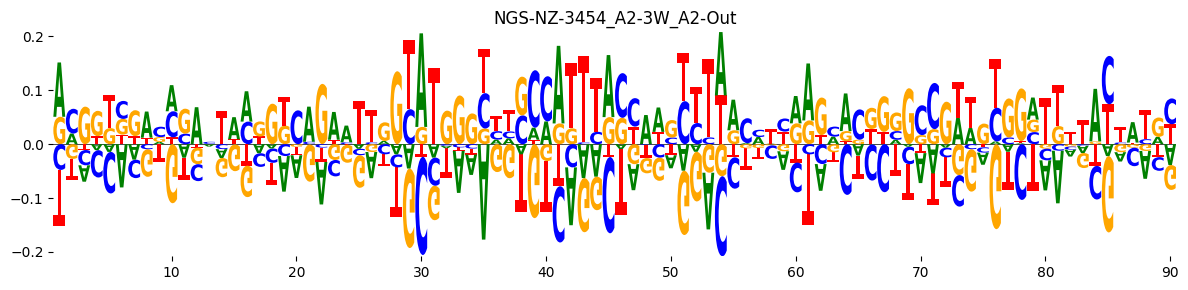

In [3]:
# Load and plot ORI A logos based on run 3454
model_names = ["NGS-NZ-3454_A1-1W_A1-Out", "NGS-NZ-3454_A1-3W_A1-Out", "NGS-NZ-3454_A2-3W_A2-Out"]
ORI_A_3454_models = {model_name: mavenn.load(model_name) for model_name in model_names}
plot_models(ORI_A_3454_models, sign_flips = [True, False, True], reverse_complement = True)

Model loaded from these files:
	NGS-NZ-3477_A1before_yl_A1_plate_yl-0n.pickle
	NGS-NZ-3477_A1before_yl_A1_plate_yl-0n.weights.h5


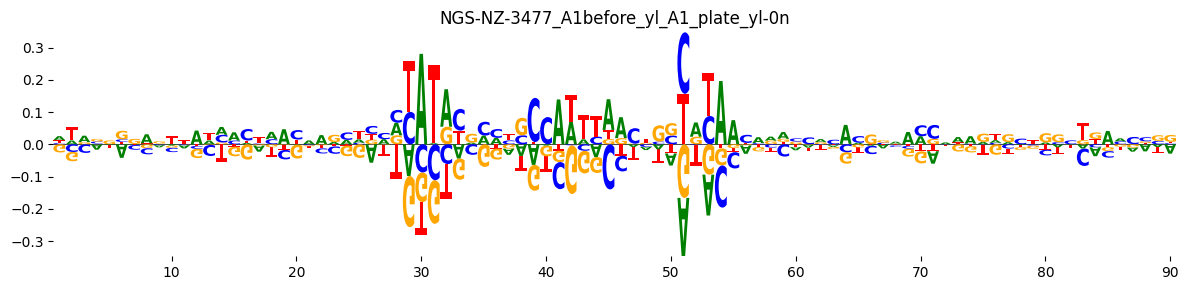

In [4]:
# Load and plot ORI A logos based on run 3477
model_names = ["NGS-NZ-3477_A1before_yl_A1_plate_yl-0n"]
ORI_A_model_3477 = {model_name: mavenn.load(model_name) for model_name in model_names}
plot_models(ORI_A_model_3477, sign_flips = [False], reverse_complement = True)

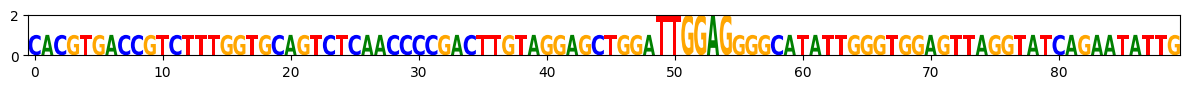

In [5]:
# Plot sequence of wild-type ORI A with motif emphasized

fig, ax = plt.subplots(1,1,figsize=[12,1])
ORI_A_library = pd.read_csv("ORI_A_library_2024-06-13_13_22_23.012484.csv")
seq = np.asarray(ORI_A_library[ORI_A_library['name'] == 'ori_A_wt']['var_seq'])[0]
seq = str(seq[21:(len(seq) - 19)])
Ori_A_wt = logomaker.sequence_to_matrix(seq = seq, to_type = 'probability', alphabet = 'dna')
#Ori_C_wt = (Ori_C_wt + pd.DataFrame(len(Ori_C_wt)*[4*[0.25]], index = Ori_C_wt.index, columns = Ori_C_wt.columns))/2
Ori_A_wt[49:55] = 2*Ori_A_wt[49:55]
wt_logo = logomaker.Logo(Ori_A_wt, ax = ax)
#wt_logo.ax.set_ylabel('WT\nsequence')
plt.tight_layout()
plt.savefig("ORI_A_wt_logo.png")

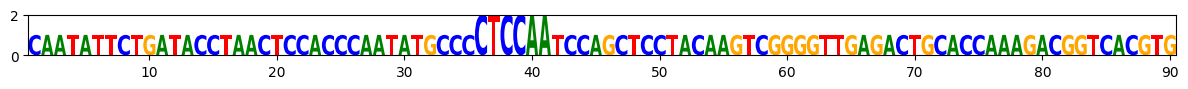

In [6]:
# Plot reverse complement of wild-type ORI A sequence with motif emphasized

complements = {"A": "T", "C": "G", "G": "C", "T": "A"}
fig, ax = plt.subplots(1,1,figsize=[12,1])
Ori_A_rc = Ori_A_wt.rename(index = dict(zip(Ori_A_wt.index, len(Ori_A_wt) - Ori_A_wt.index)), columns = complements)
rc_logo = logomaker.Logo(Ori_A_rc, ax = ax)
plt.tight_layout()
plt.savefig("ORI_A_wt_rc_logo.png")

In [7]:
# Load peaksets with sequences and length-matched controls

peakset3 = pd.read_csv("peakset3_sequence_matches.csv")
control_seqs3 = pd.read_csv("peakset3_sequence_controls.csv")
peakset4 = pd.read_csv("peakset4_sequence_matches.csv")
control_seqs4 = pd.read_csv("peakset4_sequence_controls.csv")
peakset5 = pd.read_csv("peakset5_sequence_matches.csv")
control_seqs5 = pd.read_csv("peakset5_sequence_controls.csv")

peakset3["Set"] = 3
peakset4["Set"] = 4
peakset5["Set"] = 5
control_seqs3["Set"] = 3
control_seqs4["Set"] = 4
control_seqs5["Set"] = 5

peakset3["Peak vs control"] = "Peak"
peakset4["Peak vs control"] = "Peak"
peakset5["Peak vs control"] = "Peak"
control_seqs3["Peak vs control"] = "Control"
control_seqs4["Peak vs control"] = "Control"
control_seqs5["Peak vs control"] = "Control"
All_seqs = pd.concat([peakset3, control_seqs3, peakset4, control_seqs4, peakset5, control_seqs5])
All_seqs["maxPhi"] = All_seqs["maxPhi"].astype(float)
All_seqs["Peak"] = (All_seqs["Peak vs control"] == "Peak")
All_seqs


,Unnamed: 0,chrom,chromStart,chromEnd,name,score,seq,rcSeq,maxPhi,Location of,...,p-value,Predicted probability of coming from plate,maxPhi from df,Location of best match from df,Reverse complement from df,Match sequence from df,length,Location of best match,Peak,Control
0,0,chrA,16488,17488,peak1,111.16800,CAGCTGAATCCAGAACACCCTTCGGAACAAGTCCGGGACCGTCACA...,AACTGCTCCGTGAACTGCTCCGAGCATCTGTCGCACTGACAATTTC...,-1.217014,219.0,...,0.812401,0.004112,1.486324,254,True,CAACGGAGTTGAAATTGCGGGGGGATGT,NaN,NaN,True,NaN
1,1,chrA,18950,19950,peak2,0.29103,TTTTACTCCCTCCTACTCTAGCACAGCCACAACTTTAACCCGCATT...,CAAGGTAGTAGGGTTCCCAACAGTGGAGCTTATCTCTGCCATGATC...,-0.696458,854.0,...,0.434022,0.011028,1.630773,924,True,TTGGAGGTGAAAAACGTGGCGTGCATGG,NaN,NaN,True,NaN
2,2,chrA,29906,30906,peak3,127.68100,ACTAAAAGTAGAAGCTGAGGGACTCTGGGCGTAAACGCGTAGCGAA...,ACCACGATCAGGTATAGTCGCTTCGAACTAGCACCACAAGAGCCGC...,0.263105,48.0,...,0.049285,0.103357,1.877268,83,True,TTCGGCGGGCTTGGTGGCATGCGTATGG,NaN,NaN,True,NaN
3,3,chrA,59216,60216,peak4,484.79900,TTTTTCCCGTTTAATTCCATGACTGAATGTGACTCAACCGAAATTC...,AATATCAAATGAGCCAAATCCCAACAACCCAAATCCCGTCCCAATC...,-0.394869,483.0,...,0.241653,0.021291,1.761474,518,False,TTATACACTCAAAATCAGGTCGATATGT,NaN,NaN,True,NaN
4,4,chrA,75902,76902,peak5,97.49060,AGGTGTCTGAAAAGTCGACTGTCGCTTGTAGTGTTGTGTAGTTGAG...,AGCTAACATGGAGGTTGATGCTTTGACTCGTCCTACTCTACCGAGC...,-0.581723,649.0,...,0.364070,0.014066,1.493163,587,True,TTATACTGTAAGTCTGGGACGAATTTGT,NaN,NaN,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632,632,chrF,1063658,1063908,NaN,NaN,ACATGAGCTGGCGTATCCCACTGTTTCTGCAGTGTGCTATGGGCGC...,NaN,-1.176402,NaN,...,NaN,NaN,1.238993,26,False,CTGCAGTGTGCTATGGGCGCTCTTTTGT,250.0,40.0,False,1.0
633,633,chrF,3628034,3628284,NaN,NaN,TCCATGCAGAACATAGTCCAAACATTGTTGGAGAGTCTCCATTGCC...,NaN,-2.203553,NaN,...,NaN,NaN,1.131252,27,False,TTGGAGAGTCTCCATTGCCCAGATTTCT,250.0,152.0,False,1.0
634,634,chrF,815887,816137,NaN,NaN,GTGTACCTGCCTTTACGAGTCTCATTTCGGAGCTTGAAAAACCCCG...,NaN,-1.494539,NaN,...,NaN,NaN,1.291584,58,False,TCAGAGCGTTTCCGCGGTCGTCGAATAC,250.0,21.0,False,1.0
635,635,chrF,2682533,2682783,NaN,NaN,TCCATCTTGCTGGCCTTTGATGGCTCTGTAGGATTTCGTGTGCTGG...,NaN,-2.163515,NaN,...,NaN,NaN,1.167143,221,True,ACAGAGCCATCAAAGGCCAGCAAGATGG,250.0,69.0,False,1.0


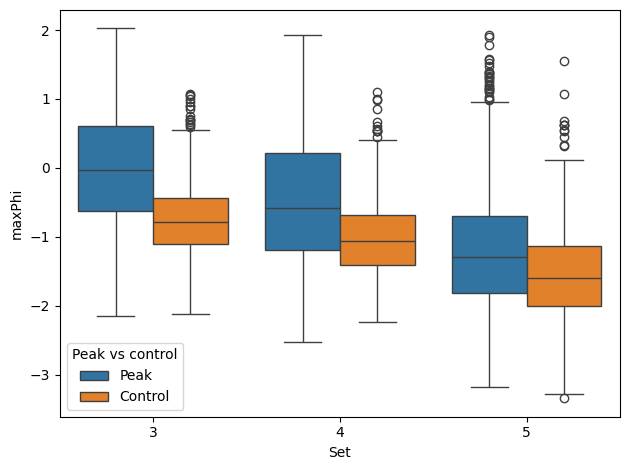

In [8]:
# Plot maximum motif scores by peakset
sns.reset_defaults()
All_seqs_reset = All_seqs.reset_index()
sns.boxplot(x = All_seqs_reset["Set"], y = pd.to_numeric(All_seqs_reset["maxPhi"], errors = 'coerce'), hue = All_seqs_reset["Peak vs control"])
plt.tight_layout()
#plt.savefig("ORI_A_model_3477_max_motif_scores.png")
plt.show()

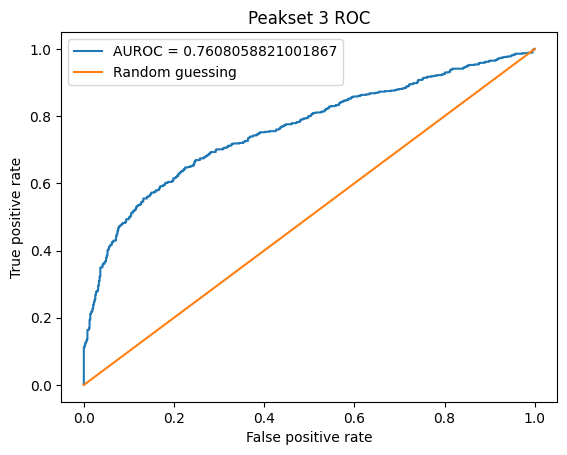

In [9]:
# Plot ROC curve based on peakset 3

peakset3_sorted = All_seqs[All_seqs["Set"] == 3].sort_values(by = "maxPhi", ascending = False)[["maxPhi", "Peak"]]
TPR = [0]
FPR = [0]
AUROC = 0
for peak in peakset3_sorted["Peak"]:
    if peak:
        TPR.append(TPR[-1] + 1)
        FPR.append(FPR[-1])
    else:
        TPR.append(TPR[-1])
        FPR.append(FPR[-1] + 1)
        AUROC = AUROC + TPR[-1]

AUROC = AUROC/(max(TPR)*max(FPR))
TPR = np.asarray(TPR)/max(TPR)
FPR = np.asarray(FPR)/max(FPR)

plt.plot(FPR, TPR, label = "AUROC = " + str(AUROC))
plt.plot([0, 1], [0, 1], label = "Random guessing")
plt.legend()
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Peakset 3 ROC")
plt.savefig("Peakset3_ROC.png")
plt.show()

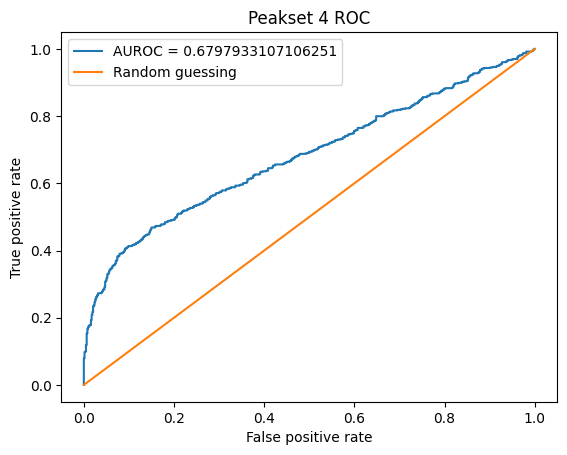

In [10]:
# Plot ROC curve based on peakset 4

peakset4_sorted = All_seqs[All_seqs["Set"] == 4].sort_values(by = "maxPhi", ascending = False)[["maxPhi", "Peak"]]
TPR = [0]
FPR = [0]
AUROC = 0
for peak in peakset4_sorted["Peak"]:
    if peak:
        TPR.append(TPR[-1] + 1)
        FPR.append(FPR[-1])
    else:
        TPR.append(TPR[-1])
        FPR.append(FPR[-1] + 1)
        AUROC = AUROC + TPR[-1]

AUROC = AUROC/(max(TPR)*max(FPR))
TPR = np.asarray(TPR)/max(TPR)
FPR = np.asarray(FPR)/max(FPR)

plt.plot(FPR, TPR, label = "AUROC = " + str(AUROC))
plt.plot([0, 1], [0, 1], label = "Random guessing")
plt.legend()
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Peakset 4 ROC")
plt.savefig("Peakset4_ROC.png")
plt.show()

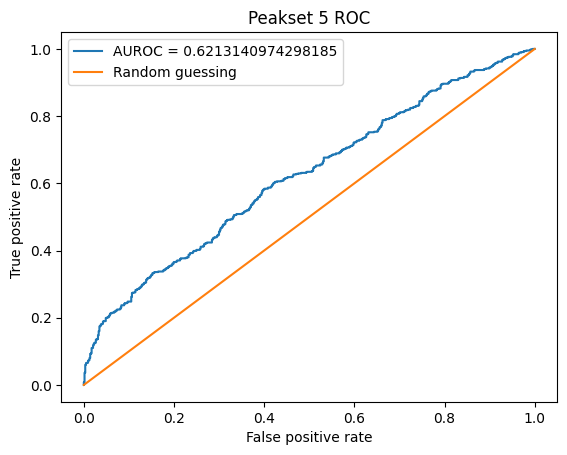

In [11]:
# Plot ROC curve based on peakset 5

peakset5_sorted = All_seqs[All_seqs["Set"] == 5].sort_values(by = "maxPhi", ascending = False)[["maxPhi", "Peak"]]
TPR = [0]
FPR = [0]
AUROC = 0
for peak in peakset5_sorted["Peak"]:
    if peak:
        TPR.append(TPR[-1] + 1)
        FPR.append(FPR[-1])
    else:
        TPR.append(TPR[-1])
        FPR.append(FPR[-1] + 1)
        AUROC = AUROC + TPR[-1]

AUROC = AUROC/(max(TPR)*max(FPR))
TPR = np.asarray(TPR)/max(TPR)
FPR = np.asarray(FPR)/max(FPR)

plt.plot(FPR, TPR, label = "AUROC = " + str(AUROC))
plt.plot([0, 1], [0, 1], label = "Random guessing")
plt.legend()
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Peakset 5 ROC")
plt.savefig("Peakset5_ROC.png")
plt.show()

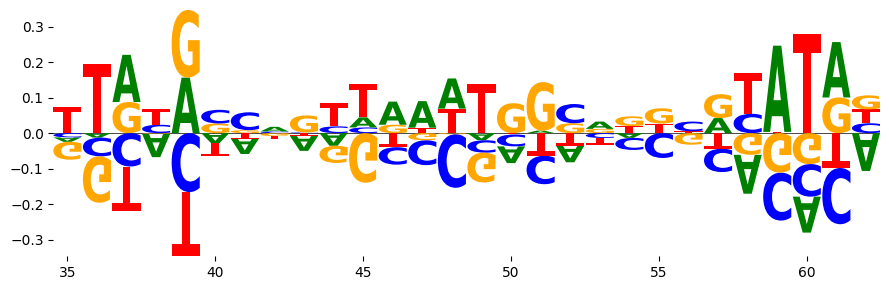

In [12]:
# Plot cropped logo

# Retrieve G-P map parameter dict and view dict keys
theta_dict = ORI_A_model_3477['NGS-NZ-3477_A1before_yl_A1_plate_yl-0n'].get_theta(gauge='uniform')
        
# Get the additive weights
lc_weights = theta_dict['theta_lc']
# Convert them to pandas dataframe
lc_df = pd.DataFrame(lc_weights, columns=ORI_A_model_3477['NGS-NZ-3477_A1before_yl_A1_plate_yl-0n'].alphabet)
lc_df = lc_df.iloc[35:63]
#lc_df

# plot logos
fig, axs = plt.subplots(1, 1, figsize=[9, 3])

# sequence logo
logo = logomaker.Logo(lc_df,  ax=axs, center_values=True)
logo.style_spines(visible=False)

plt.tight_layout()
plt.show()

In [13]:
def get_max_phi_from_df(logo_df, seq):
    encoding = {"A": (1, 0, 0, 0), "C": (0, 1, 0, 0), "G": (0, 0, 1, 0), "T": (0, 0, 0, 1)}
    complements = str.maketrans({'A':'T', 'C':'G', 'G':'C', 'T':'A'})
    rc_seq = seq[::-1].translate(complements)
    phis = [[], []]
    phis[0] = correlate(pd.DataFrame([encoding[base] for base in seq], columns = ["A", "C", "G", "T"]), logo_df, mode = 'valid').transpose()[0]
    phis[1] = correlate(pd.DataFrame([encoding[base] for base in rc_seq], columns = ["A", "C", "G", "T"]), logo_df, mode = 'valid').transpose()[0]
    if max(phis[1]) > max(phis[0]):
        location = np.argmax(phis[1])
        return(max(phis[1]), location, True, rc_seq[location:(location + len(logo_df))])
    else:
        location = np.argmax(phis[0])
        return(max(phis[0]), np.argmax(phis[0]), False, seq[location:(location + len(logo_df))])

In [14]:
# Compute motif scores based on cropped logo
peakset3["maxPhi from df"], peakset3["Location of best match from df"], peakset3["Reverse complement from df"], peakset3["Match sequence from df"] = np.asarray([get_max_phi_from_df(lc_df, seq) for seq in peakset3["seq"]]).transpose()
peakset3["maxPhi from df"] = peakset3["maxPhi from df"].astype(float)
peakset4["maxPhi from df"], peakset4["Location of best match from df"], peakset4["Reverse complement from df"], peakset4["Match sequence from df"] = np.asarray([get_max_phi_from_df(lc_df, seq) for seq in peakset4["seq"]]).transpose()
peakset4["maxPhi from df"] = peakset4["maxPhi from df"].astype(float)
peakset5["maxPhi from df"], peakset5["Location of best match from df"], peakset5["Reverse complement from df"], peakset5["Match sequence from df"] = np.asarray([get_max_phi_from_df(lc_df, seq) for seq in peakset5["seq"]]).transpose()
peakset5["maxPhi from df"] = peakset5["maxPhi from df"].astype(float)

control_seqs3["maxPhi from df"], control_seqs3["Location of best match from df"], control_seqs3["Reverse complement from df"], control_seqs3["Match sequence from df"] = np.asarray([get_max_phi_from_df(lc_df, seq) for seq in control_seqs3["seq"]]).transpose()
control_seqs3["maxPhi from df"] = control_seqs3["maxPhi from df"].astype(float)
control_seqs4["maxPhi from df"], control_seqs4["Location of best match from df"], control_seqs4["Reverse complement from df"], control_seqs4["Match sequence from df"] = np.asarray([get_max_phi_from_df(lc_df, seq) for seq in control_seqs4["seq"]]).transpose()
control_seqs4["maxPhi from df"] = control_seqs4["maxPhi from df"].astype(float)
control_seqs5["maxPhi from df"], control_seqs5["Location of best match from df"], control_seqs5["Reverse complement from df"], control_seqs5["Match sequence from df"] = np.asarray([get_max_phi_from_df(lc_df, seq) for seq in control_seqs5["seq"]]).transpose()
control_seqs5["maxPhi from df"] = control_seqs5["maxPhi from df"].astype(float)

peakset3["Set"] = 3
peakset4["Set"] = 4
peakset5["Set"] = 5
control_seqs3["Set"] = 3
control_seqs4["Set"] = 4
control_seqs5["Set"] = 5

peakset3["Peak vs control"] = "Peak"
peakset4["Peak vs control"] = "Peak"
peakset5["Peak vs control"] = "Peak"
control_seqs3["Peak vs control"] = "Control"
control_seqs4["Peak vs control"] = "Control"
control_seqs5["Peak vs control"] = "Control"
All_seqs = pd.concat([peakset3, control_seqs3, peakset4, control_seqs4, peakset5, control_seqs5])
All_seqs["maxPhi"] = All_seqs["maxPhi"].astype(float)
All_seqs["Peak"] = (All_seqs["Peak vs control"] == "Peak")
All_seqs["Control"] = (All_seqs["Peak vs control"] == "Control")
All_seqs

,Unnamed: 0,chrom,chromStart,chromEnd,name,score,seq,rcSeq,maxPhi,Location of,...,p-value,Predicted probability of coming from plate,maxPhi from df,Location of best match from df,Reverse complement from df,Match sequence from df,length,Location of best match,Peak,Control
0,0,chrA,16488,17488,peak1,111.16800,CAGCTGAATCCAGAACACCCTTCGGAACAAGTCCGGGACCGTCACA...,AACTGCTCCGTGAACTGCTCCGAGCATCTGTCGCACTGACAATTTC...,-1.217014,219.0,...,0.812401,0.004112,1.486324,254,True,CAACGGAGTTGAAATTGCGGGGGGATGT,NaN,NaN,True,False
1,1,chrA,18950,19950,peak2,0.29103,TTTTACTCCCTCCTACTCTAGCACAGCCACAACTTTAACCCGCATT...,CAAGGTAGTAGGGTTCCCAACAGTGGAGCTTATCTCTGCCATGATC...,-0.696458,854.0,...,0.434022,0.011028,1.630773,924,True,TTGGAGGTGAAAAACGTGGCGTGCATGG,NaN,NaN,True,False
2,2,chrA,29906,30906,peak3,127.68100,ACTAAAAGTAGAAGCTGAGGGACTCTGGGCGTAAACGCGTAGCGAA...,ACCACGATCAGGTATAGTCGCTTCGAACTAGCACCACAAGAGCCGC...,0.263105,48.0,...,0.049285,0.103357,1.877268,83,True,TTCGGCGGGCTTGGTGGCATGCGTATGG,NaN,NaN,True,False
3,3,chrA,59216,60216,peak4,484.79900,TTTTTCCCGTTTAATTCCATGACTGAATGTGACTCAACCGAAATTC...,AATATCAAATGAGCCAAATCCCAACAACCCAAATCCCGTCCCAATC...,-0.394869,483.0,...,0.241653,0.021291,1.761474,518,False,TTATACACTCAAAATCAGGTCGATATGT,NaN,NaN,True,False
4,4,chrA,75902,76902,peak5,97.49060,AGGTGTCTGAAAAGTCGACTGTCGCTTGTAGTGTTGTGTAGTTGAG...,AGCTAACATGGAGGTTGATGCTTTGACTCGTCCTACTCTACCGAGC...,-0.581723,649.0,...,0.364070,0.014066,1.493163,587,True,TTATACTGTAAGTCTGGGACGAATTTGT,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632,632,chrF,1063658,1063908,NaN,NaN,ACATGAGCTGGCGTATCCCACTGTTTCTGCAGTGTGCTATGGGCGC...,NaN,-1.176402,NaN,...,NaN,NaN,1.238993,26,False,CTGCAGTGTGCTATGGGCGCTCTTTTGT,250.0,40.0,False,True
633,633,chrF,3628034,3628284,NaN,NaN,TCCATGCAGAACATAGTCCAAACATTGTTGGAGAGTCTCCATTGCC...,NaN,-2.203553,NaN,...,NaN,NaN,1.131252,27,False,TTGGAGAGTCTCCATTGCCCAGATTTCT,250.0,152.0,False,True
634,634,chrF,815887,816137,NaN,NaN,GTGTACCTGCCTTTACGAGTCTCATTTCGGAGCTTGAAAAACCCCG...,NaN,-1.494539,NaN,...,NaN,NaN,1.291584,58,False,TCAGAGCGTTTCCGCGGTCGTCGAATAC,250.0,21.0,False,True
635,635,chrF,2682533,2682783,NaN,NaN,TCCATCTTGCTGGCCTTTGATGGCTCTGTAGGATTTCGTGTGCTGG...,NaN,-2.163515,NaN,...,NaN,NaN,1.167143,221,True,ACAGAGCCATCAAAGGCCAGCAAGATGG,250.0,69.0,False,True


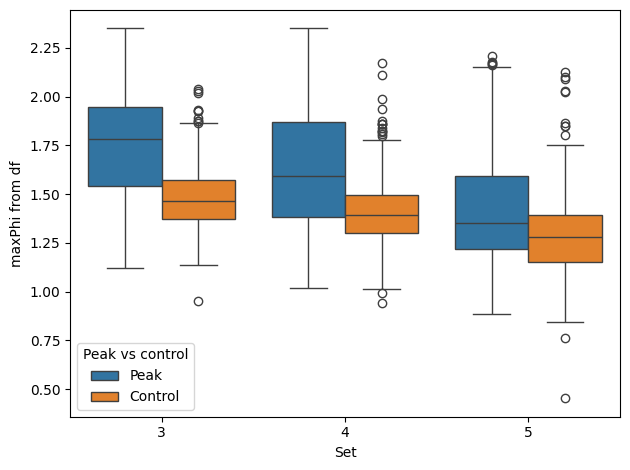

In [15]:
sns.boxplot(x = All_seqs["Set"], y = All_seqs["maxPhi from df"].astype(float), hue = All_seqs["Peak vs control"])
plt.tight_layout()
plt.savefig("ORI_A_model_3477_max_trimmed_motif_scores.png")
plt.show()

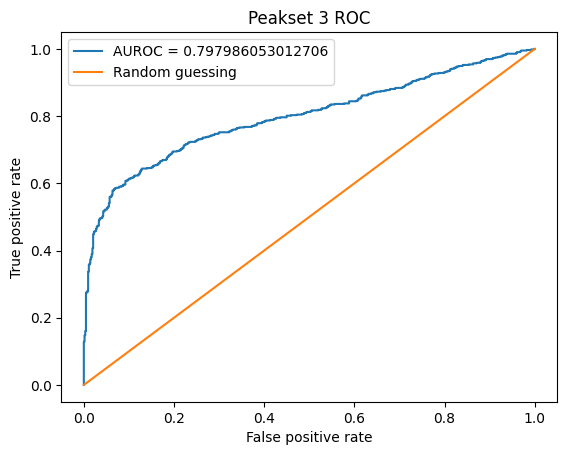

In [16]:
# Plot ROC curve based on peakset 3 and cropped logo

peakset3_sorted = All_seqs[All_seqs["Set"] == 3].sort_values(by = "maxPhi from df", ascending = False)[["maxPhi", "Peak"]]
TPR = [0]
FPR = [0]
AUROC = 0
for peak in peakset3_sorted["Peak"]:
    if peak:
        TPR.append(TPR[-1] + 1)
        FPR.append(FPR[-1])
    else:
        TPR.append(TPR[-1])
        FPR.append(FPR[-1] + 1)
        AUROC = AUROC + TPR[-1]

AUROC = AUROC/(max(TPR)*max(FPR))
TPR = np.asarray(TPR)/max(TPR)
FPR = np.asarray(FPR)/max(FPR)

plt.plot(FPR, TPR, label = "AUROC = " + str(AUROC))
plt.plot([0, 1], [0, 1], label = "Random guessing")
plt.legend()
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Peakset 3 ROC")
plt.savefig("Peakset3_ROC_trimmed_motif.png")
plt.show()

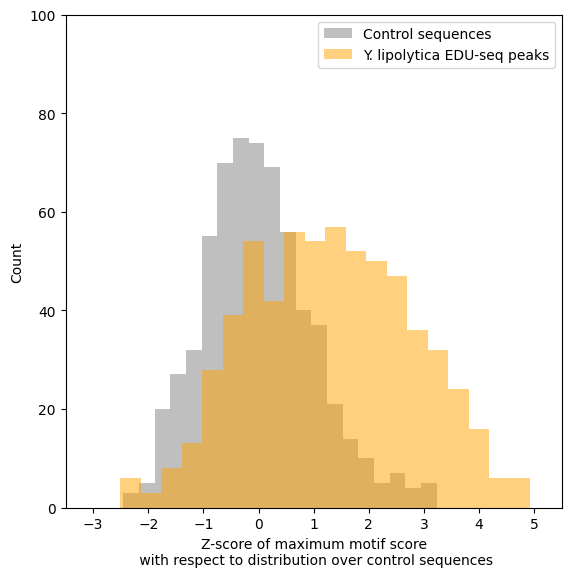

In [17]:
# Plot distributions of motif scores based on cropped logo

plt.figure(figsize=(6.4, 6.4))
control_maxPhis = peakset3_sorted[~peakset3_sorted["Peak"]]["maxPhi"]
peakset3_sorted["maxPhi"] = (peakset3_sorted["maxPhi"] - np.mean(control_maxPhis))/np.std(control_maxPhis)
plt.hist(peakset3_sorted[~peakset3_sorted["Peak"]]["maxPhi"], label = "Control sequences", bins = 20, alpha = 0.5, color = "gray")
plt.hist(peakset3_sorted[peakset3_sorted["Peak"]]["maxPhi"], label = "Y. lipolytica EDU-seq peaks", bins = 20, alpha = 0.5, color = "orange")
plt.legend()
plt.xlabel("Z-score of maximum motif score\n with respect to distribution over control sequences")
plt.ylabel("Count")
plt.xlim(-3.5, 5.5)
plt.ylim(0, 100)
plt.savefig("Peakset3_max_motif_scores_histogram.png")
plt.show()

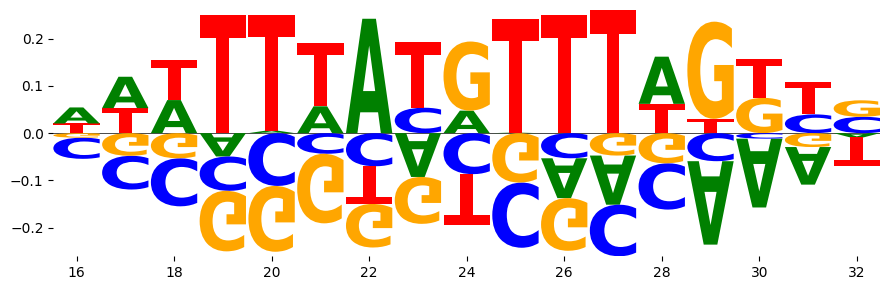

In [18]:
# Get S. cerevisiae origin motif

exp8_ars416_wt = pd.read_table("model.mi.exp8_ars416_wt.txt", index_col = "pos")
exp8_ars416_wt.rename({"val_A": "A", "val_C": "C", "val_G": "G", "val_T": "T"}, axis = 1, inplace = True)

# plot logos
fig, axs = plt.subplots(1, 1, figsize=[9, 3])

# sequence logo
logo = logomaker.Logo(exp8_ars416_wt[16:33],  ax=axs, center_values=True)
logo.style_spines(visible=False)

plt.tight_layout()
plt.show()

In [19]:
oriDB_confirmed_ARSs = pd.read_csv("oriDB_confirmed_ARSs.csv")
oriDB_confirmed_ARSs

,Unnamed: 0,chrom,chromStart,chromEnd,ARS name,seq,rcSeq,maxPhi from df,Location of best match from df,Reverse complement from df,Match sequence from df
0,0,chr1,650,1791,ARS102,TGCCCTTAATACATACGTTATACCACTTTTGCACCATATACTTACC...,AATGCTTGCCCAAAGGTATCTTTAACTTTTAATTGCTTGTTTTATT...,2.566732,1026,True,ATTTTTATGTTTAGGTG
1,1,chr1,6136,7136,ARS102.5,TTGATTAGTACTGTTGGTCTCTCATTGAAATTTTACGTGACACCAT...,ATATTTAAAGGAAAAATAACCTATTATACGGATACGGCGTATTAAA...,1.890296,502,True,ATATTTATTTTTTGAAC
2,2,chr1,7998,8548,ARS103,ACCTAATTTCATCATCAGTTAAGAAAATAGAATAACAGTTGTATGG...,TATTTGTTGCGAATGCAAAGCCCTTACTTCCTTCTAAATCCGAAAG...,1.870686,329,True,TTTTTACTATTTGGGCC
3,3,chr1,30946,31184,ARS104,GCTTTCAAAGTTTTCTTCTATAAACATACTTGTGGCAGCTTGTTTT...,TAAAAATCAAAAATTCACGTCTTATAGACAGTCGTCGGTATATATA...,2.305615,55,False,ATTTTTAAGTTTTGTTG
4,4,chr1,40716,43300,ARS105,AAAGCAGCAGTACTTTCATCATTACCTCATAATACTGTGCACACGG...,CATCTGCTACACCACTTGCAGAGACCAGTGGCAGACAGATGGCGAC...,2.012074,1196,True,TATTTTATTTTTTTTTT
...,...,...,...,...,...,...,...,...,...,...,...
405,405,chr16,776921,777152,ARS1626.5,TAATGTGTTAGTTTTTCTTTCTTTCTTTCTTTGTCTTGACGTGATT...,TTCTACGAGAAGAATAAGATAATTTTTATCTTTTACTAAAAGTATA...,2.327902,54,True,TTATTTATATTTTGGCA
406,406,chr16,819153,819393,ARS1627,AGGGGCCCTATATCTTCCCTCCTCCTTGCAATTGAATTTTGTTTGC...,TCCCTTTAACGATATAAGATTTTCTTCACGTGTTCATGTAATGGAA...,2.227002,48,True,ATTTTTATATTTATTCA
407,407,chr16,842646,842894,ARS1628,TTATGGAATTTTTCACCAATTGAAGAACTTTATGACAACAGAATGT...,CGGTTTAACGAAAAAATAGTATAAAACACGAACACACAAATAAATC...,2.209693,38,True,TTATTTAGATTTAGTTG
408,408,chr16,880854,881102,ARS1630,CATTCTTGTCAGTTTCATAACAGTTGTTTCATACGATTTCCACATG...,CTTTCGATGAAGAAAATTGTTCATAAATGTATTCTTATTACCACTA...,2.471099,57,False,TATTTTATGTTTAGGTT


In [20]:
saccharomyces_control_seqs = pd.read_csv("saccharomyces_control_seqs.csv")
saccharomyces_control_seqs

,Unnamed: 0,chrom,length,chromStart,chromEnd,seq,maxPhi,Location of best match,Reverse complement,Match sequence
0,0,chr1,1141,78065,79206,GAGACTCCTTTGCAAAGCAATCAAGAGCTGTTCAAGAGGAATTTCA...,1.998744,1017,True,ATATTTTTGTTTTGGAA
1,1,chr1,1000,136704,137704,CACACATAAATTATATTTTATACATTATTAGAAGTGAAGCTGTTGT...,1.899192,857,False,TTTTTTATTTTTGGTAT
2,2,chr1,550,68525,69075,TGGTCGCCAGCACAGAATGTATCGTACCCCTGAAGGTAGTTTTTTA...,1.700420,445,True,TCATATATATTTTTCCA
3,3,chr1,238,136620,136858,TAAATCAGAATGAAAGAGTTGGAGGGCTTCTTCCTTCGAATAAGAG...,1.746527,154,False,CATTTCATATTTAAGTT
4,4,chr1,2584,141290,143874,TCTTTCAGTGTCAGTGAAAGCGACAAAAGATGGAGTGGTTCTGTTA...,1.880334,635,True,TTTTTTTCATTTATTTG
...,...,...,...,...,...,...,...,...,...,...
405,405,chr16,231,741401,741632,TGTCTATGAAATCGAAAACCCCCAGCCATGCATAGATCAAACTTCA...,1.502518,29,True,ATTTTGTCCTTTAGGGA
406,406,chr16,240,487700,487940,TTTTTCTTGAGCTTCAGCTTGAACCTTTGGAAAAATGTTACTCAAG...,1.494246,61,False,AATATTACACTTTGTAA
407,407,chr16,248,917131,917379,ACATTTAGCTCTCTTTCATTGACCATCTTTAATTGATTCAATTCGC...,1.980460,24,True,GTTTTTTTGTTTAGATG
408,408,chr16,248,787382,787630,TATGGATCAAAACTTACTTCCGGCCGAAAAATTCACTCATAACTAA...,1.694328,134,True,ATATTCTTATTTTGATG


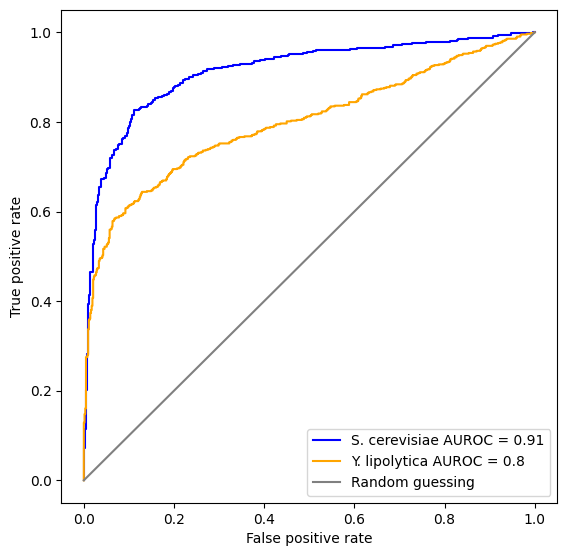

In [21]:
# Plot ROC curve for S. cerevisiae motif together with that for Y. lipolytica

plt.figure(figsize=(6.4, 6.4))
oriDB_confirmed_ARSs["ARS"] = True
saccharomyces_control_seqs["ARS"] = False
oriDB_confirmed_ARSs_with_controls = pd.concat([oriDB_confirmed_ARSs.rename({"maxPhi from df": "maxPhi"}, axis = 1), saccharomyces_control_seqs])
oriDB_confirmed_ARSs_with_controls["maxPhi"] = oriDB_confirmed_ARSs_with_controls["maxPhi"].astype(float)
oriDB_confirmed_ARSs_with_controls = oriDB_confirmed_ARSs_with_controls.sort_values(by = "maxPhi", ascending = False)
TPR = [0]
FPR = [0]
AUROC = 0
for peak in oriDB_confirmed_ARSs_with_controls["ARS"]:
    if peak:
        TPR.append(TPR[-1] + 1)
        FPR.append(FPR[-1])
    else:
        TPR.append(TPR[-1])
        FPR.append(FPR[-1] + 1)
        AUROC = AUROC + TPR[-1]

AUROC = AUROC/(max(TPR)*max(FPR))
TPR = np.asarray(TPR)/max(TPR)
FPR = np.asarray(FPR)/max(FPR)

plt.plot(FPR, TPR, label = "S. cerevisiae AUROC = " + str(round(AUROC, 2)), color = "blue")

TPR = [0]
FPR = [0]
AUROC = 0
for peak in peakset3_sorted["Peak"]:
    if peak:
        TPR.append(TPR[-1] + 1)
        FPR.append(FPR[-1])
    else:
        TPR.append(TPR[-1])
        FPR.append(FPR[-1] + 1)
        AUROC = AUROC + TPR[-1]

AUROC = AUROC/(max(TPR)*max(FPR))
TPR = np.asarray(TPR)/max(TPR)
FPR = np.asarray(FPR)/max(FPR)

plt.plot(FPR, TPR, label = "Y. lipolytica AUROC = " + str(round(AUROC, 2)), color = "orange")
plt.plot([0, 1], [0, 1], label = "Random guessing", color = "gray")
plt.legend()
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
#plt.title("Y. lipolytica vs S. cerevisiae ROCs")
plt.savefig("EDU-seq_motif_ROCs.png")
plt.show()

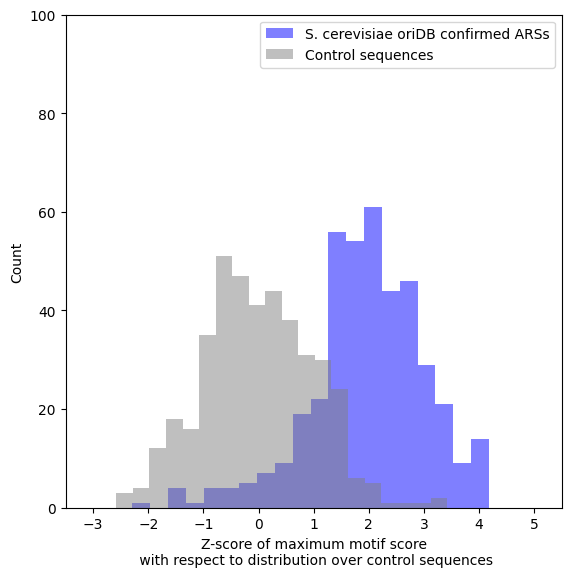

In [22]:
# Plot distributions of motif scores for S. cerevisiae

plt.figure(figsize=(6.4, 6.4))
oriDB_confirmed_ARSs["maxPhi from df"] = (oriDB_confirmed_ARSs["maxPhi from df"] - np.mean(saccharomyces_control_seqs["maxPhi"].astype(float)))/np.std(saccharomyces_control_seqs["maxPhi"].astype(float))
saccharomyces_control_seqs["maxPhi"] = (saccharomyces_control_seqs["maxPhi"].astype(float) - np.mean(saccharomyces_control_seqs["maxPhi"].astype(float)))/np.std(saccharomyces_control_seqs["maxPhi"].astype(float))
plt.hist(oriDB_confirmed_ARSs["maxPhi from df"], bins = 20, alpha = 0.5, label = "S. cerevisiae oriDB confirmed ARSs", color = "blue")
plt.hist(saccharomyces_control_seqs["maxPhi"], bins = 20, alpha = 0.5, label = "Control sequences", color = "gray")
plt.xlabel("Z-score of maximum motif score\n with respect to distribution over control sequences")
plt.ylabel("Count")
plt.legend()
plt.xlim(-3.5, 5.5)
plt.ylim(0, 100)
plt.savefig("exp8_ars416_wt_motif_scores.png")
plt.show()